<a href="https://colab.research.google.com/github/Goutham-26/DSA/blob/main/Assesment_02_08_26.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

In [2]:
sample_df = pd.read_csv('/content/sample_submission_M0L0uXE.csv')
sample_df.head()

,employee_id,is_promoted
0,8724,0
1,74430,0
2,72255,0
3,38562,0
4,64486,0


In [3]:
train_df = pd.read_csv('/content/train_LZdllcl.csv')
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [4]:
train_df.shape

(54808, 14)

In [5]:
train_df.isna().sum()

,0
employee_id,0
department,0
region,0
education,2409
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,4124
length_of_service,0


In [6]:
train_df['education'] = train_df['education'].fillna(train_df['education'].mode()[0])

In [7]:
train_df['previous_year_rating'] = train_df['previous_year_rating'].fillna(train_df['previous_year_rating'].median())

In [8]:
train_df.isna().sum()

,0
employee_id,0
department,0
region,0
education,0
gender,0
recruitment_channel,0
no_of_trainings,0
age,0
previous_year_rating,0
length_of_service,0


In [9]:
train_df.drop_duplicates()
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


Target distribution (is_promoted):
is_promoted
0    0.91483
1    0.08517
Name: proportion, dtype: float64


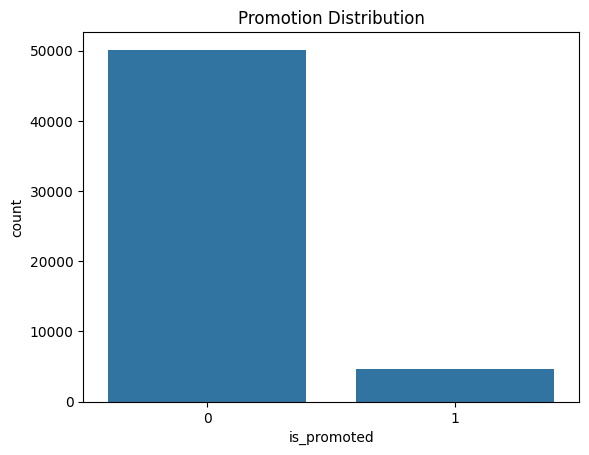

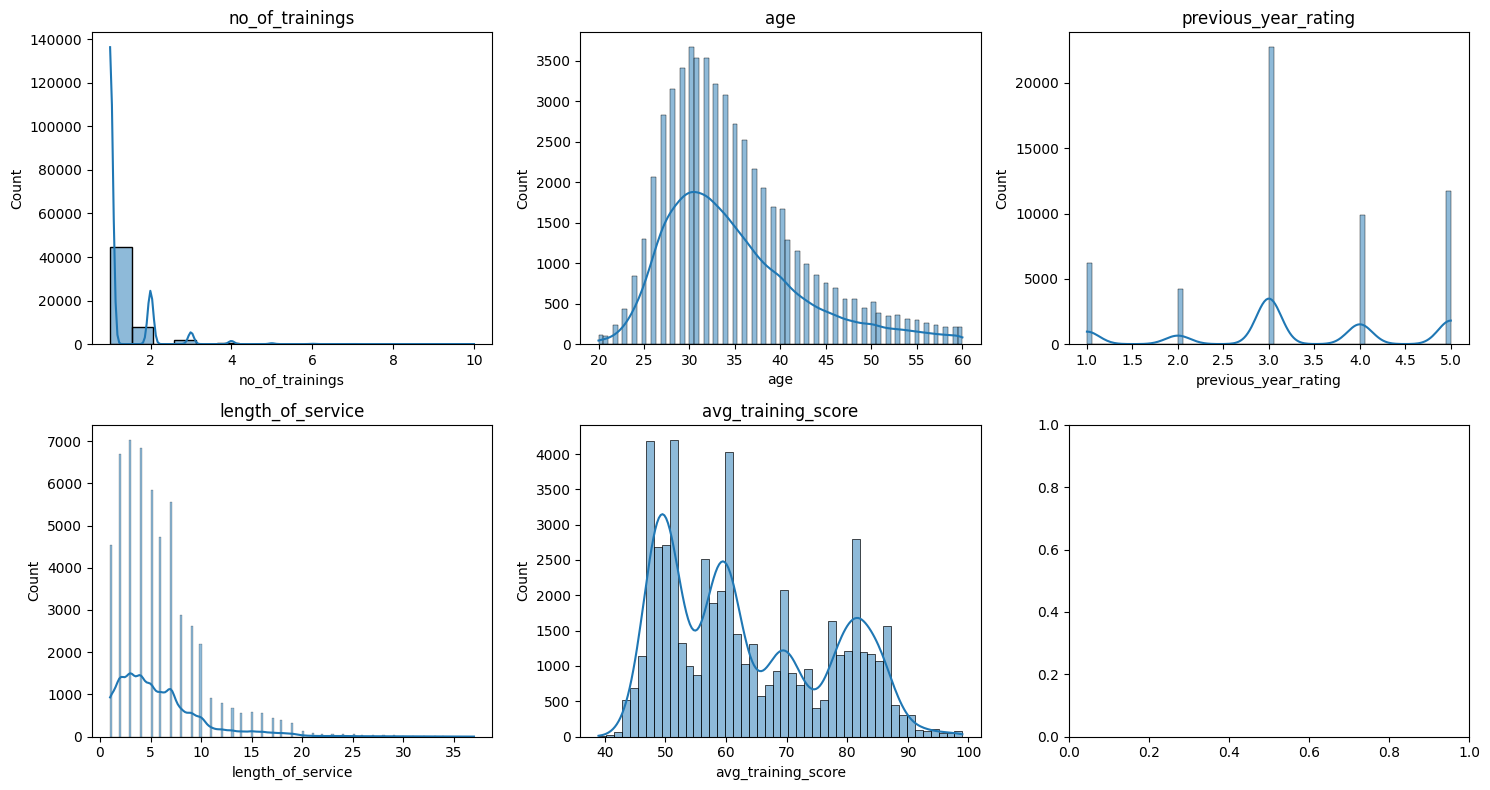


Promotion rate by department:
department
Technology           0.107593
Procurement          0.096386
Analytics            0.095665
Operations           0.090148
Finance              0.081230
Sales & Marketing    0.072031
R&D                  0.069069
HR                   0.056245
Legal                0.051011
Name: is_promoted, dtype: float64

Promotion rate by education:
education
Master's & above    0.098559
Below Secondary     0.083230
Bachelor's          0.080096
Name: is_promoted, dtype: float64

Promotion rate by gender:
gender
f    0.089934
m    0.083151
Name: is_promoted, dtype: float64

Promotion rate by recruitment_channel:
recruitment_channel
referred    0.120841
sourcing    0.085013
other       0.083952
Name: is_promoted, dtype: float64

Promotion rate by KPIs_met >80%:
KPIs_met >80%
0    0.039587
1    0.169094
Name: is_promoted, dtype: float64

Promotion rate by awards_won?:
awards_won?
0    0.076749
1    0.440157
Name: is_promoted, dtype: float64


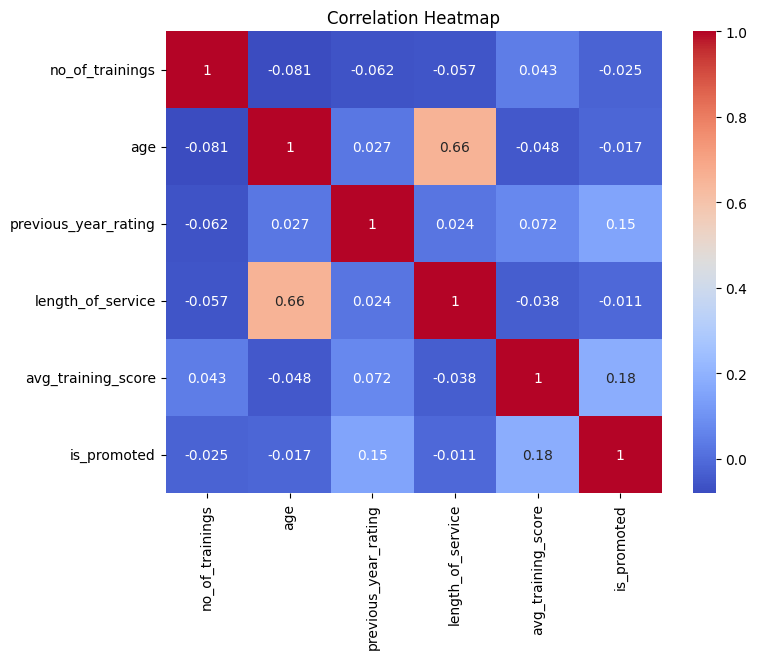

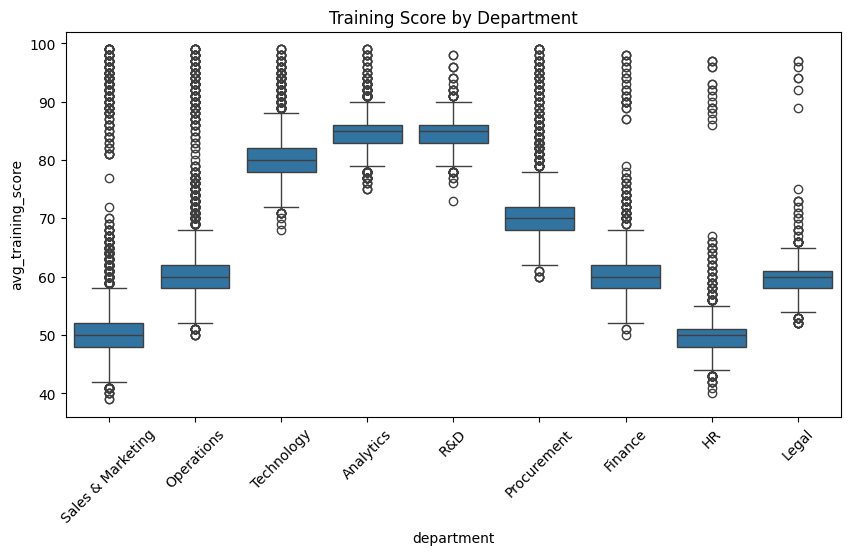

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt
print("Target distribution (is_promoted):")
print(train_df['is_promoted'].value_counts(normalize=True))

sns.countplot(x='is_promoted', data=train_df)
plt.title('Promotion Distribution')
plt.show()

numerical_columns = ['no_of_trainings', 'age', 'previous_year_rating',
                      'length_of_service', 'avg_training_score']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
for ax, col in zip(axes.flat, numerical_columns):
    sns.histplot(train_df[col], kde=True, ax=ax)
    ax.set_title(col)
plt.tight_layout()
plt.show()


categorical_columns = ['department', 'education', 'gender', 'recruitment_channel']

for col in categorical_columns:
    promo_rate = train_df.groupby(col)['is_promoted'].mean().sort_values(ascending=False)
    print(f"\nPromotion rate by {col}:\n{promo_rate}")


for col in ['KPIs_met >80%', 'awards_won?']:
    print(f"\nPromotion rate by {col}:")
    print(train_df.groupby(col)['is_promoted'].mean())

plt.figure(figsize=(8, 6))
sns.heatmap(train_df[numerical_columns + ['is_promoted']].corr(),
            annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

plt.figure(figsize=(10, 5))
sns.boxplot(x='department', y='avg_training_score', data=train_df)
plt.xticks(rotation=45)
plt.title('Training Score by Department')
plt.show()

In [11]:
train_df['education'] = train_df['education'].fillna(train_df['education'].mode()[0])
train_df['previous_year_rating'] = train_df['previous_year_rating'].fillna(train_df['previous_year_rating'].median())
train_df.head()

,employee_id,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,65438,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,65141,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,7513,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,2542,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,48945,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [12]:
train_df = train_df.drop_duplicates()

In [13]:
train_df_copy = train_df['employee_id']
train_df = train_df.drop(columns=['employee_id'])
train_df.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,region_7,Master's & above,f,sourcing,1,35,5.0,8,1,0,49,0
1,Operations,region_22,Bachelor's,m,other,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,region_19,Bachelor's,m,sourcing,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,region_23,Bachelor's,m,other,2,39,1.0,10,0,0,50,0
4,Technology,region_26,Bachelor's,m,other,1,45,3.0,2,0,0,73,0


In [14]:
education_order = {'Below Secondary': 0, "Bachelor's": 1, "Master's & above": 2}
train_df['education'] = train_df['education'].map(education_order)

In [15]:
region_freq = train_df['region'].value_counts(normalize=True)
train_df['region'] = train_df['region'].map(region_freq)
train_df.head()

,department,region,education,gender,recruitment_channel,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,is_promoted
0,Sales & Marketing,0.088363,2,f,sourcing,1,35,5.0,8,1,0,49,0
1,Operations,0.117282,1,m,other,1,30,5.0,4,0,0,60,0
2,Sales & Marketing,0.015947,1,m,sourcing,1,34,3.0,7,0,0,50,0
3,Sales & Marketing,0.021438,1,m,other,2,39,1.0,10,0,0,50,0
4,Technology,0.041235,1,m,other,1,45,3.0,2,0,0,73,0


In [16]:
train_df = pd.get_dummies(train_df, columns=['department', 'recruitment_channel'], drop_first=True)

In [17]:
for col in train_df.select_dtypes(include='bool').columns:
    train_df[col] = train_df[col].astype(int)

print("First 5 rows of train_df after converting boolean columns to int:")
display(train_df.head())

First 5 rows of train_df after converting boolean columns to int:


,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,...,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,recruitment_channel_referred,recruitment_channel_sourcing
0,0.088363,2,f,1,35,5.0,8,1,0,49,...,0,0,0,0,0,0,1,0,0,1
1,0.117282,1,m,1,30,5.0,4,0,0,60,...,0,0,0,1,0,0,0,0,0,0
2,0.015947,1,m,1,34,3.0,7,0,0,50,...,0,0,0,0,0,0,1,0,0,1
3,0.021438,1,m,2,39,1.0,10,0,0,50,...,0,0,0,0,0,0,1,0,0,0
4,0.041235,1,m,1,45,3.0,2,0,0,73,...,0,0,0,0,0,0,0,1,0,0


In [18]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

for column in train_df.columns:
    if train_df[column].dtype == 'object':
        train_df[column] = le.fit_transform(train_df[column])
        print(f"Column '{column}' has been label encoded.")


print("\nFirst 5 rows of x_train after label encoding:")
display(train_df.head())

Column 'gender' has been label encoded.

First 5 rows of x_train after label encoding:


,region,education,gender,no_of_trainings,age,previous_year_rating,length_of_service,KPIs_met >80%,awards_won?,avg_training_score,...,department_Finance,department_HR,department_Legal,department_Operations,department_Procurement,department_R&D,department_Sales & Marketing,department_Technology,recruitment_channel_referred,recruitment_channel_sourcing
0,0.088363,2,0,1,35,5.0,8,1,0,49,...,0,0,0,0,0,0,1,0,0,1
1,0.117282,1,1,1,30,5.0,4,0,0,60,...,0,0,0,1,0,0,0,0,0,0
2,0.015947,1,1,1,34,3.0,7,0,0,50,...,0,0,0,0,0,0,1,0,0,1
3,0.021438,1,1,2,39,1.0,10,0,0,50,...,0,0,0,0,0,0,1,0,0,0
4,0.041235,1,1,1,45,3.0,2,0,0,73,...,0,0,0,0,0,0,0,1,0,0


In [19]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, f1_score, confusion_matrix

X = train_df.drop(columns=['is_promoted'])
y = train_df['is_promoted']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [20]:
final_model = RandomForestClassifier(class_weight='balanced', random_state=42)
final_model.fit(X, y)

val_preds = final_model.predict(X_val)
val_probs = final_model.predict_proba(X_val)[:, 1]

print("Baseline Random Forest:")
print(classification_report(y_val, val_preds, target_names=['Not Promoted', 'Promoted']))
print("ROC-AUC:", roc_auc_score(y_val, val_probs))

Baseline Random Forest:
              precision    recall  f1-score   support

Not Promoted       1.00      1.00      1.00     10028
    Promoted       0.99      1.00      1.00       934

    accuracy                           1.00     10962
   macro avg       1.00      1.00      1.00     10962
weighted avg       1.00      1.00      1.00     10962

ROC-AUC: 0.9999499260742299


In [21]:
from sklearn.metrics import f1_score
import numpy as np

val_probs = final_model.predict_proba(X_val)[:, 1]

thresholds = np.arange(0.1, 0.9, 0.05)
f1_scores = []

for t in thresholds:
    preds_at_t = (val_probs >= t).astype(int)
    f1_scores.append(f1_score(y_val, preds_at_t))

best_threshold = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print(f"Best threshold: {best_threshold:.2f}")
print(f"Best F1 at that threshold: {best_f1:.4f}")
print(f"F1 at default 0.5 threshold: {f1_scores[list(thresholds).index(0.5)] if 0.5 in thresholds else 'N/A'}")

Best threshold: 0.35
Best F1 at that threshold: 0.9973
F1 at default 0.5 threshold: N/A


In [22]:
test_df = pd.read_csv('/content/test_2umaH9m.csv')

test_df['education'] = test_df['education'].fillna(test_df['education'].mode()[0])
test_df['previous_year_rating'] = test_df['previous_year_rating'].fillna(test_df['previous_year_rating'].median())

test_df = test_df.drop_duplicates()

test_ids = test_df['employee_id']
test_df = test_df.drop(columns=['employee_id'])

education_order = {'Below Secondary': 0, "Bachelor's": 1, "Master's & above": 2}
test_df['education'] = test_df['education'].map(education_order)

test_df['gender'] = test_df['gender'].map({'f': 0, 'm': 1})

region_freq_test = test_df['region'].value_counts(normalize=True)
test_df['region'] = test_df['region'].map(region_freq_test)

test_df = pd.get_dummies(test_df, columns=['department', 'recruitment_channel'], drop_first=True)

print("Test shape:", test_df.shape)

Test shape: (23490, 20)


In [23]:
X = train_df.drop(columns=['is_promoted'])   # train's feature columns, the reference

test_df = test_df.reindex(columns=X.columns, fill_value=0)

print("Columns match:", list(test_df.columns) == list(X.columns))

Columns match: True


In [25]:
test_probs = final_model.predict_proba(test_df)[:, 1]
test_predictions = (test_probs >= best_threshold).astype(int)

print("Predicted promotion rate on test:", test_predictions.mean())

Predicted promotion rate on test: 0.05087271179225202


In [26]:
submission = pd.DataFrame({
    'employee_id': test_ids,
    'is_promoted': test_predictions
})

submission.to_csv('submission_rf_tuned_threshold.csv', index=False)


In [27]:
from google.colab import files
files.download('submission_rf_tuned_threshold.csv')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>